In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Exploring Global Terrorism Patterns & Trends.xlsx")

In [4]:
data

,iso3c,Country,Rank,Score,Incidents,Fatalities,Injuries,Hostages,Year
0,IRQ,Iraq,1,9.599967,1288,2086,5050,16,2012
1,PAK,Pakistan,2,9.152620,638,1322,2297,160,2012
2,AFG,Afghanistan,3,9.134265,507,1511,2612,67,2012
3,SYR,Syria,4,8.238079,168,1014,1833,71,2012
4,YEM,Yemen,5,8.098513,219,651,798,121,2012
...,...,...,...,...,...,...,...,...,...
1788,TKM,Turkmenistan,93,0.000000,0,0,0,0,2022
1789,TLS,Timor-Leste,93,0.000000,0,0,0,0,2022
1790,TTO,Trinidad and Tobago,93,0.000000,0,0,0,0,2022
1791,ZMB,Zambia,93,0.000000,0,0,0,0,2022


In [5]:
data.describe()

,Rank,Score,Incidents,Fatalities,Injuries,Hostages,Year
count,1793.000000,1793.000000,1793.000000,1793.000000,1793.000000,1793.000000,1793.00000
mean,71.691578,2.442817,26.699944,53.537646,74.588957,10.149470,2017.00000
std,35.235705,2.654876,109.500965,253.912698,415.669549,82.306937,3.16316
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2012.00000
25%,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.00000
50%,82.000000,1.534965,0.000000,0.000000,0.000000,0.000000,2017.00000
75%,106.000000,4.419243,4.000000,2.000000,4.000000,0.000000,2020.00000
max,112.000000,10.000000,1673.000000,4514.000000,9479.000000,2727.000000,2022.00000


In [6]:
data.isna().sum()

iso3c         0
Country       0
Rank          0
Score         0
Incidents     0
Fatalities    0
Injuries      0
Hostages      0
Year          0
dtype: int64

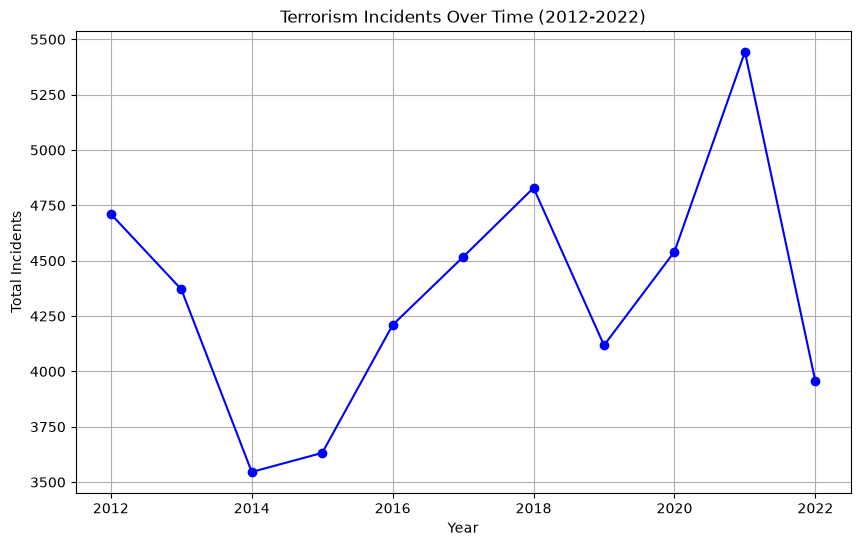

In [8]:
# Group the data by year and sum the incident counts
yearly_totals = data.groupby('Year')['Incidents'].sum().reset_index()

# Create a line chart to visualize the trend
plt.figure(figsize=(10, 6))
plt.plot(yearly_totals['Year'], yearly_totals['Incidents'], marker='o', linestyle='-', color='b')
plt.title('Terrorism Incidents Over Time (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.grid(True)

# Show the plot
plt.show()


In [11]:
# Group the data by country and calculate the sum of incidents
total_incidents_by_country = data.groupby('Country')['Incidents'].sum().reset_index()

# Sort the data in descending order to get the top 5 countries with the highest total incidents
top_5_countries = total_incidents_by_country.sort_values(by='Incidents', ascending=False).head(5)

# Print the top 5 countries with the highest number of total incidents
print(top_5_countries)


         Country  Incidents
66          Iraq      11183
0    Afghanistan       4443
109     Pakistan       3358
130      Somalia       2951
63         India       2872


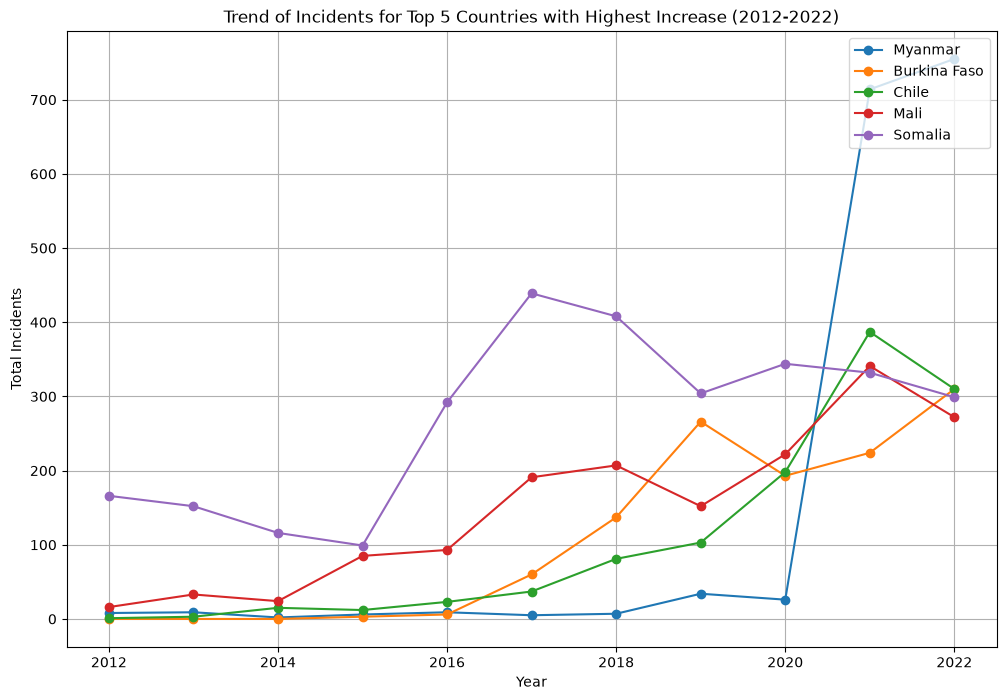

In [12]:
# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Group the data by year and country and calculate the sum of incidents
yearly_totals = data.groupby(['Year', 'Country'])['Incidents'].sum().reset_index()

# Pivot the table to have years as columns and countries as rows
pivot_table = yearly_totals.pivot(index='Country', columns='Year', values='Incidents').fillna(0)

# Calculate the increase in incidents for each country from 2012 to 2022
increase = pivot_table[2022] - pivot_table[2012]

# Sort countries based on the increase in incidents in descending order
top_countries = increase.sort_values(ascending=False).head(5).index

# Filter the data for the top 5 countries
top_countries_data = pivot_table.loc[top_countries]

# Create a line chart to visualize the trend
plt.figure(figsize=(12, 8))

for country in top_countries_data.index:
    plt.plot(top_countries_data.columns, top_countries_data.loc[country], marker='o', linestyle='-', label=country)

plt.title('Trend of Incidents for Top 5 Countries with Highest Increase (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.legend(loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


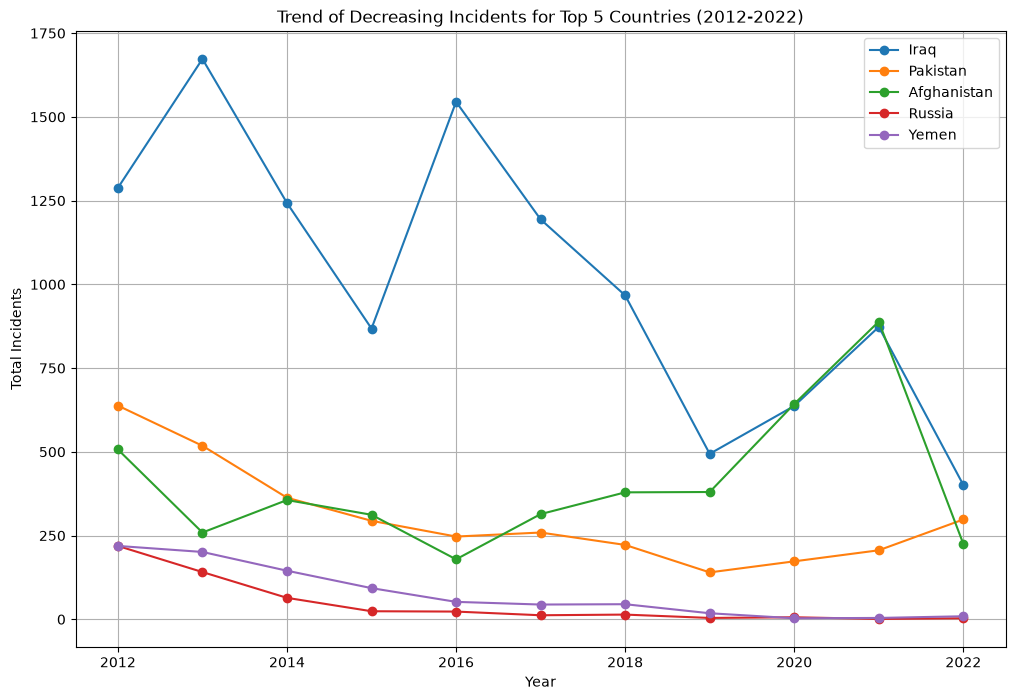

In [13]:
import matplotlib.pyplot as plt

# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Group the data by year and country and calculate the sum of incidents
yearly_totals = data.groupby(['Year', 'Country'])['Incidents'].sum().reset_index()

# Pivot the table to have years as columns and countries as rows
pivot_table = yearly_totals.pivot(index='Country', columns='Year', values='Incidents').fillna(0)

# Calculate the decrease in incidents for each country from 2012 to 2022
decrease = pivot_table[2012] - pivot_table[2022]

# Sort countries based on the decrease in incidents in descending order
top_countries_decrease = decrease.sort_values(ascending=False).head(5).index

# Filter the data for the top 5 countries with the greatest decrease
top_countries_decrease_data = pivot_table.loc[top_countries_decrease]

# Create a line chart to visualize the trend of decreasing incidents
plt.figure(figsize=(12, 8))

for country in top_countries_decrease_data.index:
    plt.plot(top_countries_decrease_data.columns, top_countries_decrease_data.loc[country], marker='o', linestyle='-', label=country)

plt.title('Trend of Decreasing Incidents for Top 5 Countries (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.legend(loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


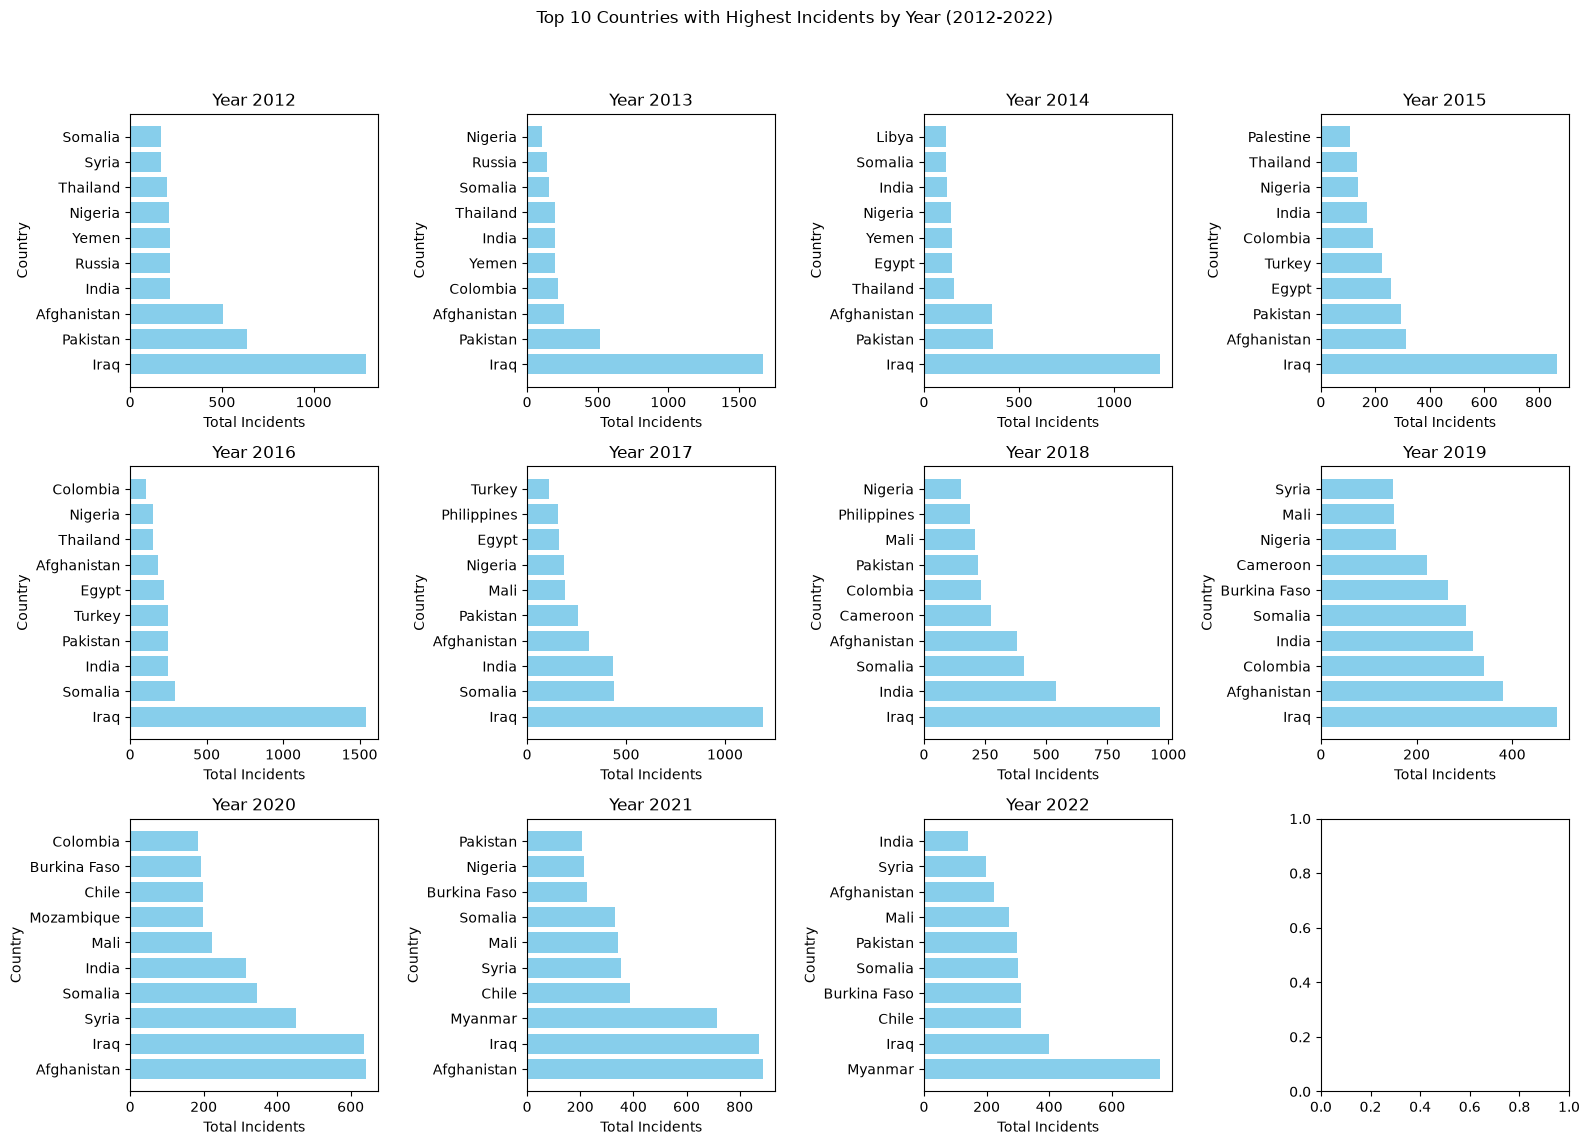

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the "Year" column is treated as an integer
data["Year"] = data["Year"].astype(int)

# Initialize an empty DataFrame to store the results
top_countries_by_year = pd.DataFrame(columns=["Year", "Country", "Incidents"])

# Create a figure with subplots for each year
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
fig.suptitle("Top 10 Countries with Highest Incidents by Year (2012-2022)")

# Loop through the years from 2012 to 2022
for i, year in enumerate(range(2012, 2023)):
    # Filter the dataset for the current year
    incidents_year = data[data["Year"] == year]

    # Group the data by country and calculate the sum of incidents
    top_countries_year = (
        incidents_year.groupby("Country")["Incidents"].sum().reset_index()
    )

    # Sort the data in descending order to get the top 10 countries
    top_10_countries_year = top_countries_year.sort_values(
        by="Incidents", ascending=False
    ).head(10)

    # Add the year to the results
    top_10_countries_year["Year"] = year

    # Concatenate the results for the current year to the overall results DataFrame
    top_countries_by_year = pd.concat(
        [top_countries_by_year, top_10_countries_year], ignore_index=True
    )

    # Create a bar chart for the current year
    row, col = i // 4, i % 4
    ax = axs[row, col]

    ax.barh(
        top_10_countries_year["Country"],
        top_10_countries_year["Incidents"],
        color="skyblue",
    )
    ax.set_title(f"Year {year}")
    ax.set_xlabel("Total Incidents")
    ax.set_ylabel("Country")
#adjust layout
plt.tight_layout(rect=[0,0.03,1,0.95])

plt.show()

In [17]:
# Group the data by year and calculate the sum of fatalities
total_fatalities_by_year = data.groupby('Year')['Fatalities'].sum().reset_index()

# Sort the data in descending order to get the top 5 years with the highest total fatalities
top_5_years = total_fatalities_by_year.sort_values(by='Fatalities', ascending=False).head(5)

# Print the top 5 years with the highest number of total fatalities
print(top_5_years)


   Year  Fatalities
3  2015       10881
4  2016       10372
1  2013       10317
2  2014       10129
0  2012        9227


In [18]:
import pandas as pd

# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Filter the dataset for the year 2015 (Fixed syntax error)
fatalities_2015 = data[data['Year'] == 2015]

# Group the data by country and calculate the sum of fatalities for 2015
fatalities_by_country_2015 = fatalities_2015.groupby('Country')['Fatalities'].sum().reset_index()

# Sort the data in descending order to get the top 10 countries with the most fatalities in 2015
top_10_countries_2015 = fatalities_by_country_2015.sort_values(by='Fatalities', ascending=False).head(10)

# Print the top 10 countries with the most fatalities in 2015
print(top_10_countries_2015)


         Country  Fatalities
66          Iraq        2974
105      Nigeria        2003
0    Afghanistan        1008
109     Pakistan         658
41         Egypt         481
160        Yemen         458
130      Somalia         335
23      Cameroon         292
149       Turkey         286
83         Libya         234


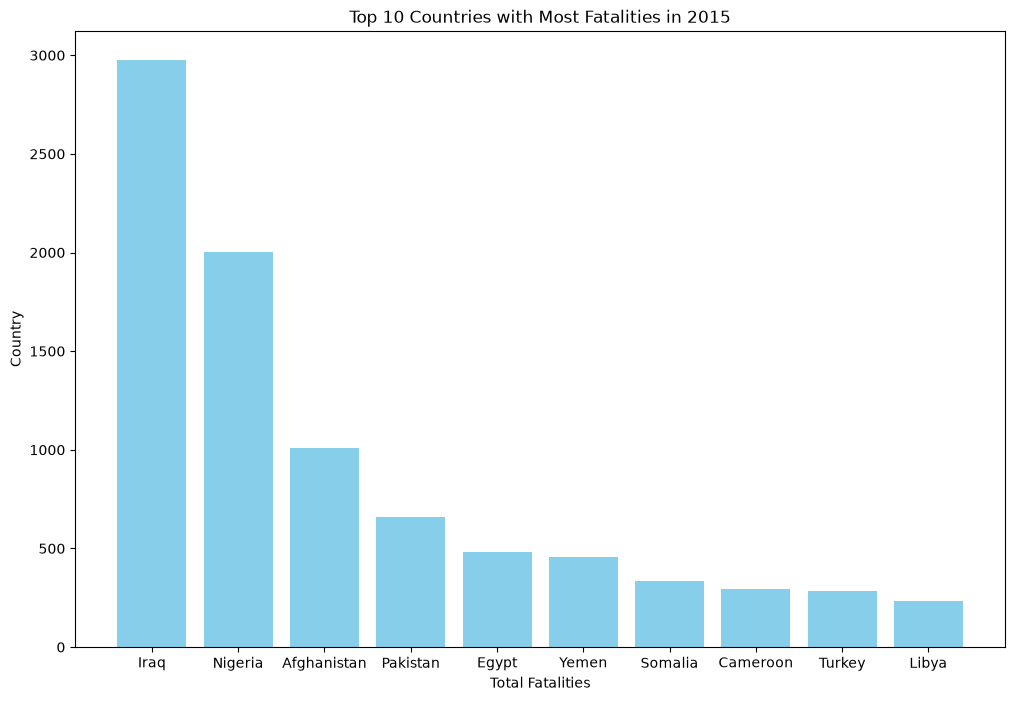

In [19]:
# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Filter the dataset for the year 2015
fatalities_2015 = data[data['Year'] == 2015]

# Group the data by country and calculate the sum of fatalities for 2015
fatalities_by_country_2015 = fatalities_2015.groupby('Country')['Fatalities'].sum().reset_index()

# Sort the data in descending order to get the top 10 countries with the most fatalities in 2015
top_10_countries_2015 = fatalities_by_country_2015.sort_values(by='Fatalities', ascending=False).head(10)

# Create a bar chart to visualize the top 10 countries with the most fatalities in 2015
plt.figure(figsize=(12, 8))
plt.bar(top_10_countries_2015['Country'], top_10_countries_2015['Fatalities'], color='skyblue')
plt.title('Top 10 Countries with Most Fatalities in 2015')
plt.xlabel('Total Fatalities')
plt.ylabel('Country')

# Show the plot
plt.show()


In [20]:
# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Filter the dataset for rows where "Rank" is equal to 1
rank_1_data = data[data['Rank'] == 1]

# Count the occurrences of each unique country with rank 1
rank_1_counts = rank_1_data['Country'].value_counts()

# Print the unique countries and their respective counts
for country, count in rank_1_counts.items():
    print(f'Country: {country}, Count: {count}')


Country: Iraq, Count: 7
Country: Afghanistan, Count: 4


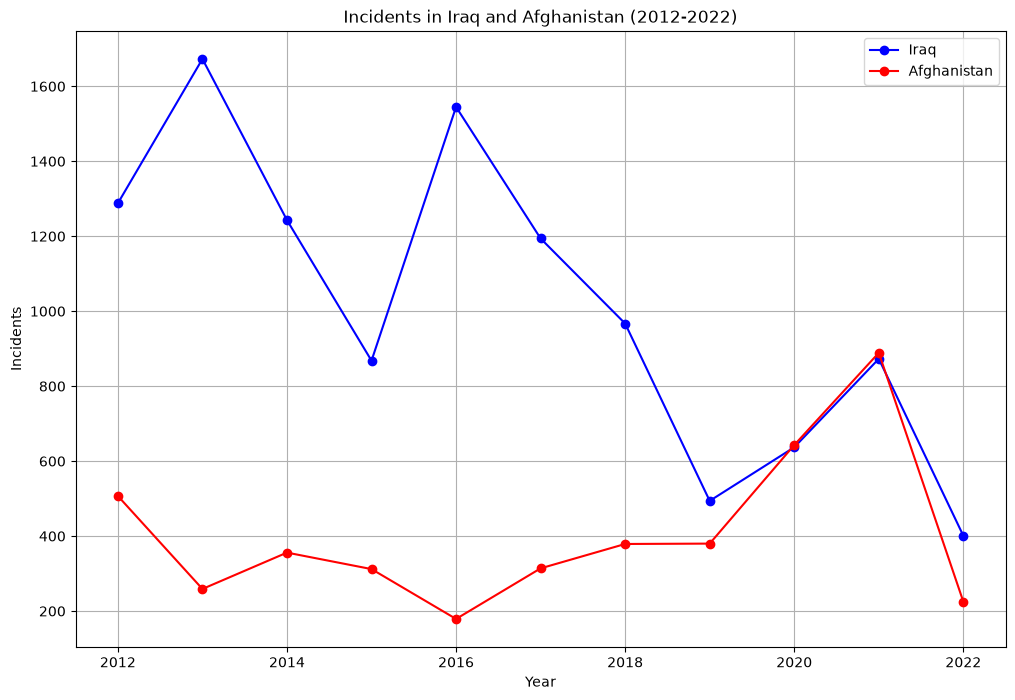

In [21]:
# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Filter the dataset for Iraq and Afghanistan
iraq_data = data[data['Country'] == 'Iraq']
afghanistan_data = data[data['Country'] == 'Afghanistan']

# Create a line plot to visualize incidents (you can change 'Incidents' to the desired variable)
plt.figure(figsize=(12, 8))
plt.plot(iraq_data['Year'], iraq_data['Incidents'], label='Iraq', marker='o', linestyle='-', color='blue')
plt.plot(afghanistan_data['Year'], afghanistan_data['Incidents'], label='Afghanistan', marker='o', linestyle='-', color='red')

plt.title('Incidents in Iraq and Afghanistan (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Incidents')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


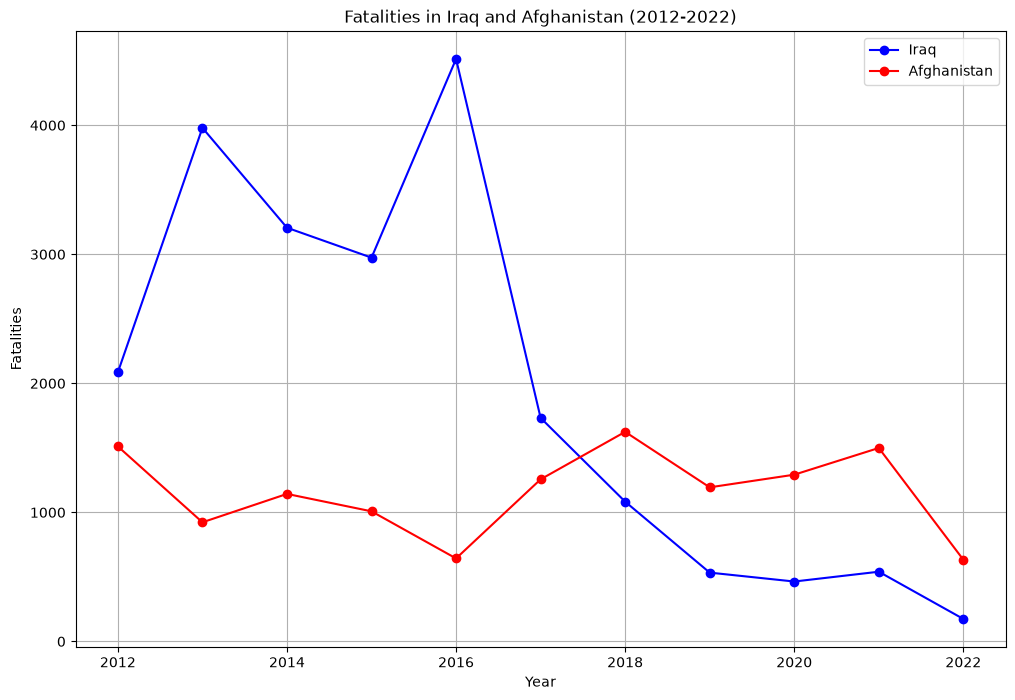

In [22]:
# Ensure the "Year" column is treated as an integer
data['Year'] = data['Year'].astype(int)

# Filter the dataset for Iraq and Afghanistan
iraq_data = data[data['Country'] == 'Iraq']
afghanistan_data = data[data['Country'] == 'Afghanistan']

# Create a line plot to visualize fatalities
plt.figure(figsize=(12, 8))
plt.plot(iraq_data['Year'], iraq_data['Fatalities'], label='Iraq', marker='o', linestyle='-', color='blue')
plt.plot(afghanistan_data['Year'], afghanistan_data['Fatalities'], label='Afghanistan', marker='o', linestyle='-', color='red')

plt.title('Fatalities in Iraq and Afghanistan (2012-2022)')
plt.xlabel('Year')
plt.ylabel('Fatalities')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


               Score  Incidents  Fatalities  Injuries  Hostages
Score       1.000000   0.516868    0.479365  0.410757  0.263119
Incidents   0.516868   1.000000    0.860467  0.863206  0.282083
Fatalities  0.479365   0.860467    1.000000  0.912888  0.318144
Injuries    0.410757   0.863206    0.912888  1.000000  0.317053
Hostages    0.263119   0.282083    0.318144  0.317053  1.000000


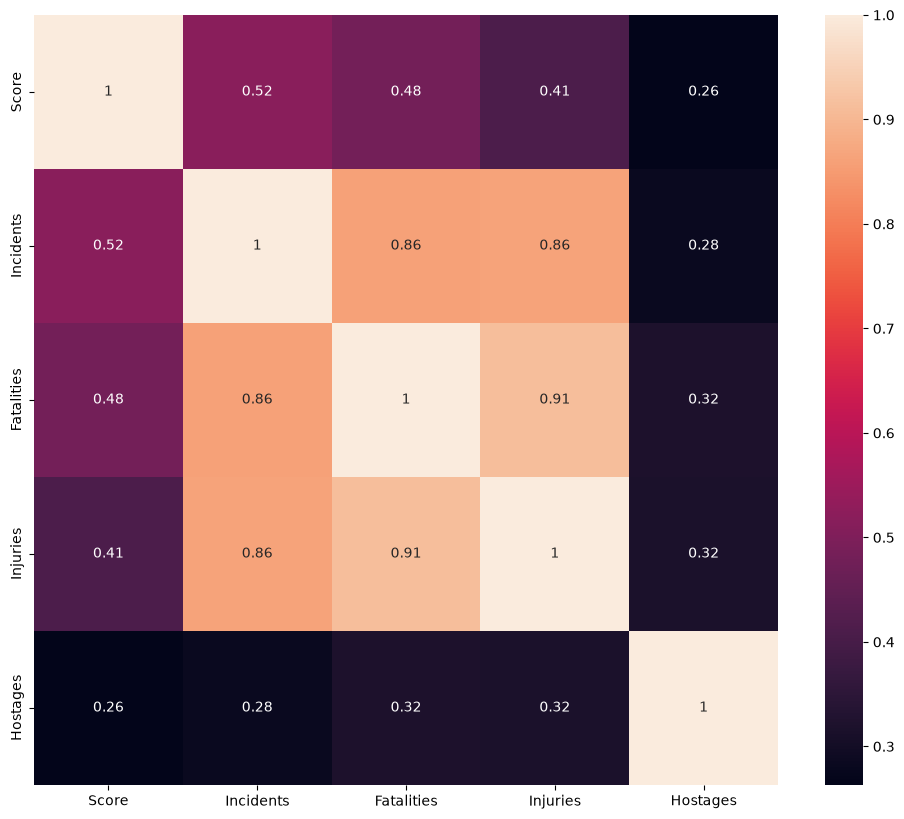

In [23]:
# Calculate the correlation matrix
correlation_matrix = data[['Score', 'Incidents', 'Fatalities', 'Injuries', 'Hostages']].corr()

# Print the correlation matrix
print(correlation_matrix)

# Print the heatmap to visualize above correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True)
plt.show()
